In [2]:
pip install pandas scikit-learn xgboost matplotlib

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   --- ------------------------------------ 7.1/72.0 MB 36.4 MB/s eta 0:00:02
   -------- ------------------------------- 14.9/72.0 MB 36.2 MB/s eta 0:00:02
   -------------- ------------------------- 25.7/72.0 MB 40.7 MB/s eta 0:00:02
   ------------------ --------------------- 34.1/72.0 MB 40.8 MB/s eta 0:00:01
   ------------------------- -------------- 45.4/72.0 MB 43.1 MB/s eta 0:00:01
   ---------------------------- ----------- 51.1/72.0 MB 40.7 MB/s eta 0:00:01
   ---------------------------------- ----- 62.1/72.0 MB 42.6 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 43.6 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 39.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

try:
    df = pd.read_csv('dataset.csv')
    
    print(f"Original shape of the dataset: {df.shape}")
    print(f"Original 'Target' values: {df['Target'].unique()}")
    
    df_filtered = df[df['Target'] != 'Enrolled'].copy()
    
    print(f"\nShape of dataset after removing 'Enrolled': {df_filtered.shape}")
    print(f"New 'Target' values: {df_filtered['Target'].unique()}")
    
    df_filtered.to_csv('dataset_filtered.csv', index=False)

Original shape of the dataset: (4424, 35)
Original 'Target' values: ['Dropout' 'Graduate' 'Enrolled']

Shape of dataset after removing 'Enrolled': (3630, 35)
New 'Target' values: ['Dropout' 'Graduate']


Libraries loaded successfully.
Loaded 'dataset_filtered.csv'. Shape: (3630, 35)
Target classes are: ['Dropout' 'Graduate']
Data split: 2904 training samples, 726 testing samples.

--- Training the XGBoost model... ---
Model training complete.

--- XGBoost Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.93      0.83      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726


--- YOUR PRECISE ACCURACY ---
Exact Accuracy: 0.9104683195592287
-------------------------------

XGBoost ROC-AUC Score: 0.9565

--- Generating Charts... ---
Saved 'xgboost_confusion_matrix.png'
Saved 'xgboost_roc_curve.png'


C:\Users\farha\AppData\Local\Temp\ipykernel_29920\6330918.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved 'xgboost_feature_importance.png'

Displaying all charts. Close the chart windows to finish the script.


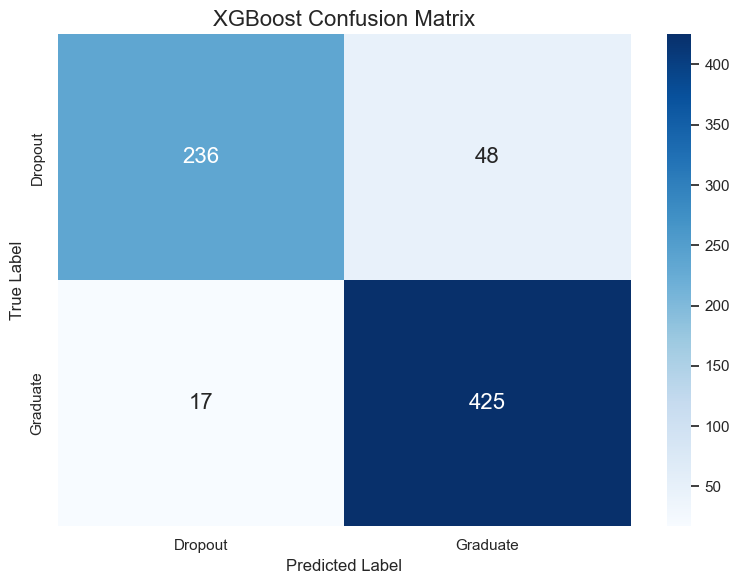

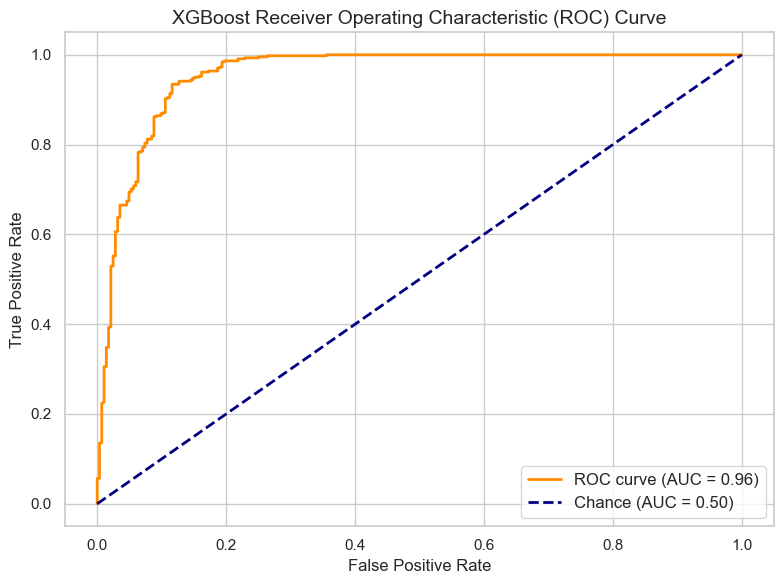

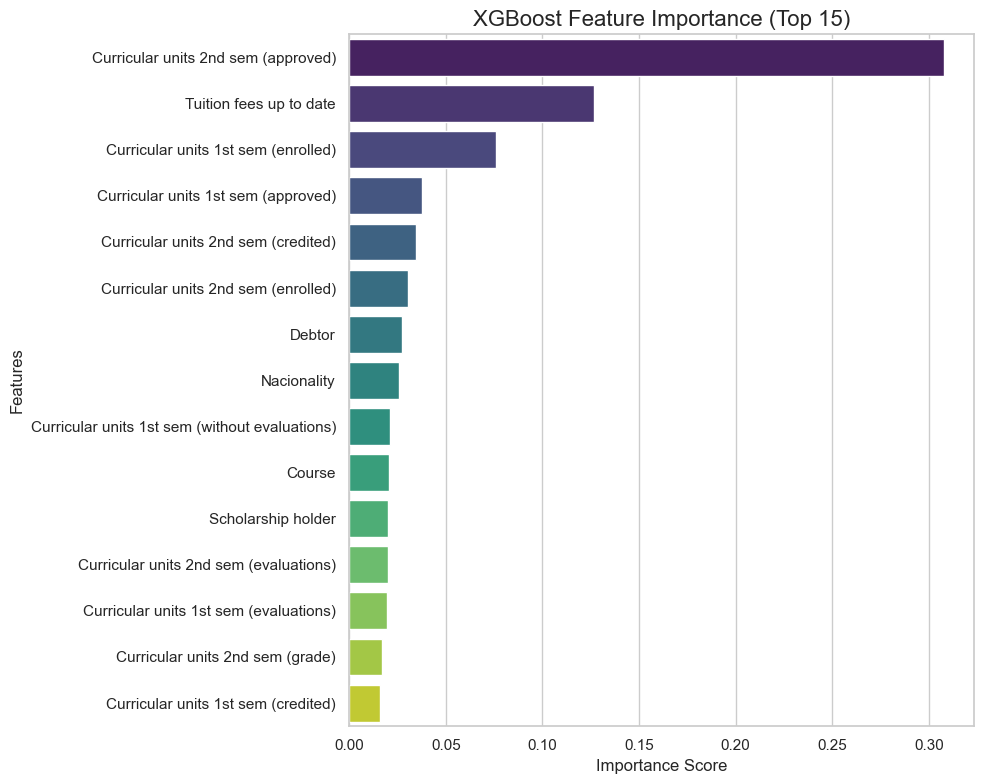


--- Analysis Complete ---


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

try:
    df = pd.read_csv('dataset_filtered.csv')
    print(f"Loaded 'dataset_filtered.csv'. Shape: {df.shape}")

TARGET_COL = 'Target'

X = df.drop(TARGET_COL, axis=1)

le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

class_names = le.classes_
print(f"Target classes are: {class_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y        
)
print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")

print("\n Training the XGBoost model... ")

model = xgb.XGBClassifier(
    objective='binary:logistic',
    seed=42,
    eval_metric='logloss'  
)

model.fit(X_train, y_train)
print("Model training complete.")

print("\n--- XGBoost Model Evaluation ---")

y_pred = model.predict(X_test)


y_pred_proba = model.predict_proba(X_test)[:, 1] 

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

exact_accuracy = accuracy_score(y_test, y_pred)
print("\n--- YOUR PRECISE ACCURACY ---")
print(f"Exact Accuracy: {exact_accuracy}")
print("-------------------------------\n")

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"XGBoost ROC-AUC Score: {auc_score:.4f}")


sns.set_theme(style="whitegrid")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16})
plt.title('XGBoost Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png') 
print("Saved 'xgboost_confusion_matrix.png'")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('XGBoost Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.savefig('xgboost_roc_curve.png') 
print("Saved 'xgboost_roc_curve.png'")


#  plotting
importance_data = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': model.feature_importances_
})

# Sort by importance and get top 15
importance_data = importance_data.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_data, 
    palette='viridis' 
)
plt.title('XGBoost Feature Importance (Top 15)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout() 
plt.savefig('xgboost_feature_importance.png') 
print("Saved 'xgboost_feature_importance.png'")


plt.show()

--- Loading Data and Training Model ---
Loaded 'dataset_filtered.csv'. Shape: (3630, 35)
Training model on full dataset...
Model training complete.

--- Generating Chart (Top 15)... ---


C:\Users\farha\AppData\Local\Temp\ipykernel_29920\3143416215.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved 'xgboost_feature_importance_top15_colors.png' with new colors.
Displaying chart. Close the chart window to exit.


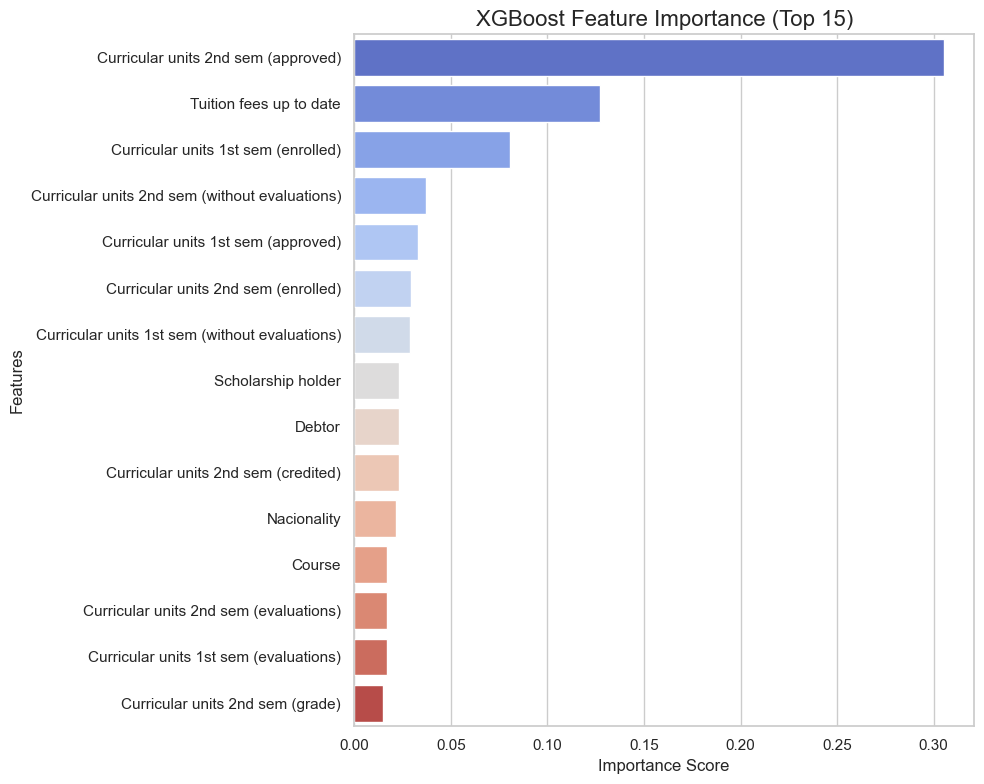

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

try:
    df = pd.read_csv('dataset_filtered.csv')
    print(f"Loaded 'dataset_filtered.csv'. Shape: {df.shape}")

TARGET_COL = 'Target'
X = df.drop(TARGET_COL, axis=1)
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

model = xgb.XGBClassifier(
    objective='binary:logistic',
    seed=42,
    eval_metric='logloss'
)
model.fit(X, y)
print("Model training complete.")

print("\n--- Generating Chart (Top 15)... ---")
sns.set_theme(style="whitegrid")

importance_data = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance_data = importance_data.sort_values(by='Importance', ascending=False).head(15)

new_palette = 'coolwarm'

plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_data,
    palette=new_palette  
)


plt.title('XGBoost Feature Importance (Top 15)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.savefig('xgboost_feature_importance_top15_colors.png') 

print("Saved 'xgboost_feature_importance_top15_colors.png' with new colors.")
print("Displaying chart. Close the chart window to exit.")

plt.show()

--- 3-CLASS XGBOOST ANALYSIS (FOR FINAL REPORT) ---
Loaded 'dataset.csv'. Shape: (4424, 35)
Target classes are: ['Dropout' 'Enrolled' 'Graduate']
Data split: 3539 training samples, 885 testing samples.

--- Training the 3-Class XGBoost model... ---
Model training complete.

--- XGBoost Model Evaluation (3-Class) ---
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.49      0.43      0.46       159
    Graduate       0.81      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.69      0.69       885
weighted avg       0.75      0.76      0.75       885


--- YOUR KEY METRIC ---
XGBoost (Macro) ROC-AUC Score: 0.8831
-----------------------

--- Generating Charts... ---
Saved 'xgboost_confusion_matrix_3CLASS.png'


C:\Users\farha\AppData\Local\Temp\ipykernel_29920\101761902.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved 'xgboost_feature_importance_3CLASS.png'

--- Analysis Complete ---
Close the chart windows to exit.


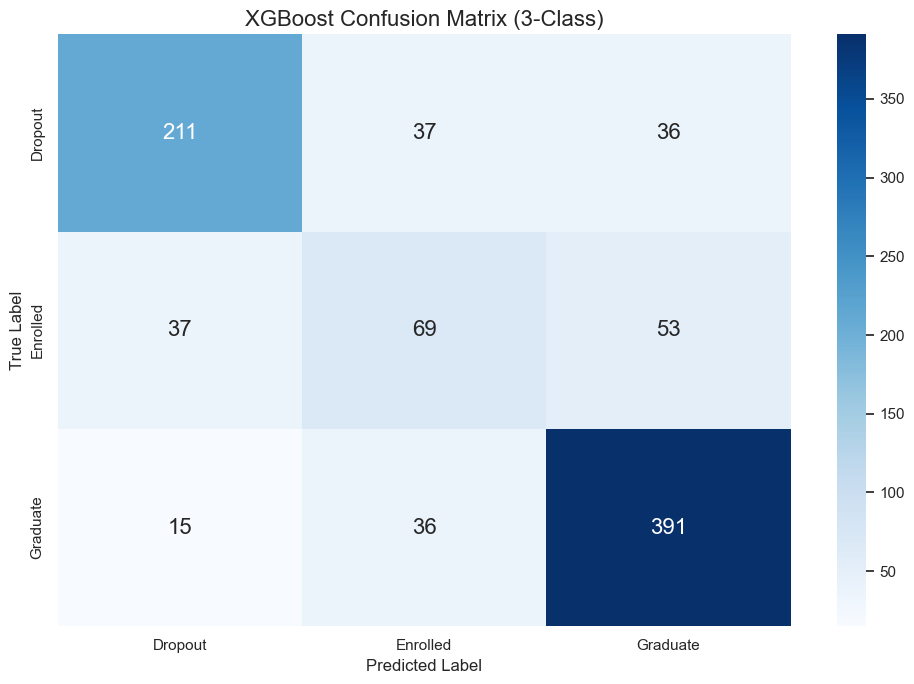

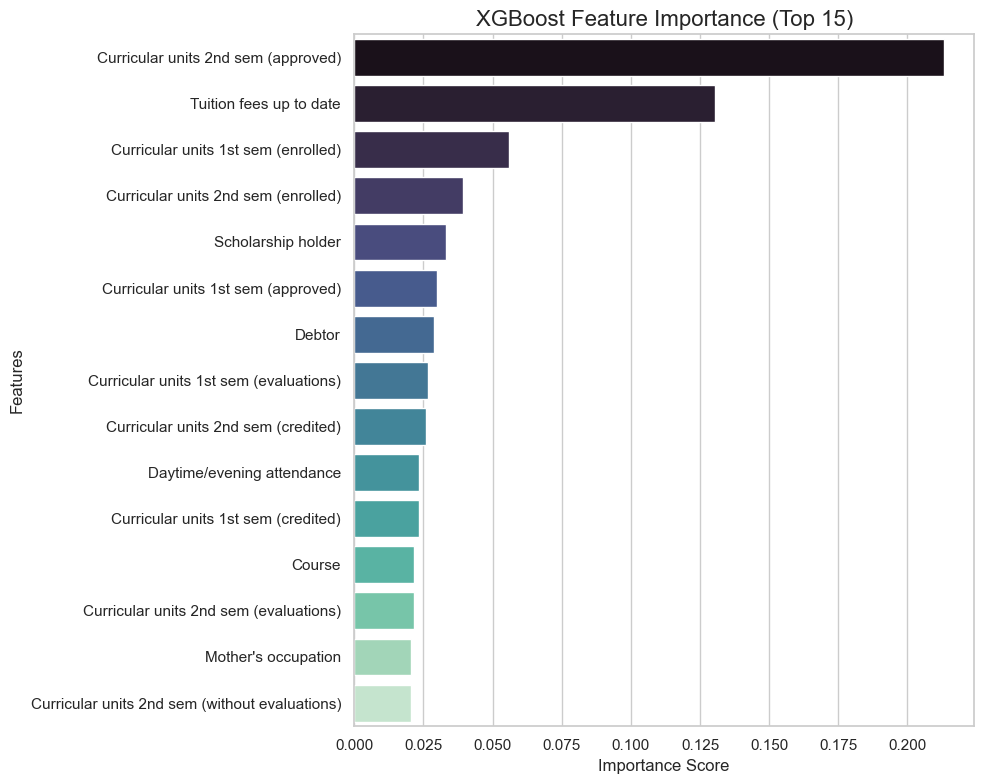

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

try:
    
    df = pd.read_csv('dataset.csv')
    print(f"Loaded 'dataset.csv'. Shape: {df.shape}")

TARGET_COL = 'Target'

X = df.drop(TARGET_COL, axis=1)

le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

class_names = le.classes_
print(f"Target classes are: {class_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")

print("\n--- Training the 3-Class XGBoost model... ---")

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names), 
    seed=42,
    eval_metric='mlogloss' 
)

model.fit(X_train, y_train)
print("Model training complete.")

print("\n--- XGBoost Model Evaluation (3-Class) ---")

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

y_pred_proba = model.predict_proba(X_test)
y_test_binarized = label_binarize(y_test, classes=range(len(class_names)))

auc_score = roc_auc_score(
    y_test_binarized, 
    y_pred_proba, 
    average='macro', 
    multi_class='ovr'
)
print("\n YOUR KEY METRIC ---")
print(f"XGBoost (Macro) ROC-AUC Score: {auc_score:.4f}")
print("-----------------------")

print("\n--- Generating Charts... ---")
sns.set_theme(style="whitegrid")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16})
plt.title('XGBoost Confusion Matrix (3-Class)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix_3CLASS.png')
print("Saved 'xgboost_confusion_matrix_3CLASS.png'")

importance_data = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': model.feature_importances_
})
importance_data = importance_data.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_data, 
    palette='mako'
)
plt.title('XGBoost Feature Importance (Top 15)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('xgboost_feature_importance_3CLASS.png')
print("Saved 'xgboost_feature_importance_3CLASS.png'")

print("\n--- Analysis Complete ---")
print("Close the chart windows to exit.")

plt.show()